In [22]:
import torch
import torch.nn as nn

class FirstLayer(nn.Module):
    def __init__(self):
        super(FirstLayer, self).__init__()
        self.layer = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU()
        )

    def forward(self, x):
        return self.layer(x)
    
class ThirdLayer(nn.Module):
    def __init__(self):
        super(ThirdLayer, self).__init__()
        self.layer = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU()
        )

    def forward(self, x):
        return self.layer(x)

class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        # Only first and third layers in Model
        self.layer = nn.ModuleList()
        self.layer.append(FirstLayer())
        self.layer.append(ThirdLayer())

    def forward(self, x):
        x = self.layer[0](x)
        x = self.layer[1](x)
        x = self.layer[2](x)
        return x

# Example usage
batch_size = 32
num_channels = 2
embedding_size = 512
input_tensor = torch.randn(batch_size, 512 , num_channels, embedding_size)  # Replace `batch_size` with the actual batch size
input_tensor = input_tensor.view(batch_size*num_channels, 512, embedding_size)

input_tensor = torch.randn(batch_size*num_channels, 512)


In [23]:
class SecondLayer(nn.Module):
    def __init__(self):
        super(SecondLayer, self).__init__()
        self.layer = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU()
        )

    def forward(self, x):
        # x = x.view(batch_size*512, num_channels, embedding_size)
        # print(x.shape)
        x = self.layer(x)
        # x = x.view(batch_size*num_channels, 512, embedding_size)
        # print(x.shape)
        return x

# DefinehiddenustomModel class that ahiddencondLayer
class customModel(Model):
    def __init__(self):
        # super(customModel, self).__init__()
        # self.layer.insert(1 , SecondLayer())
        super().__init__()
        self.layer.insert(1 , SecondLayer())

    # def forward(self, x):
    #     super().forward(x)


    # def forward(self, x):
    #     x = super().forward(x)
    #     x = self.second_layer(x)
    #     return x

In [24]:
custom_model = customModel()
custom_model

customModel(
  (layer): ModuleList(
    (0): FirstLayer(
      (layer): Sequential(
        (0): Linear(in_features=512, out_features=256, bias=True)
        (1): ReLU()
      )
    )
    (1): SecondLayer(
      (layer): Sequential(
        (0): Linear(in_features=256, out_features=128, bias=True)
        (1): ReLU()
      )
    )
    (2): ThirdLayer(
      (layer): Sequential(
        (0): Linear(in_features=128, out_features=64, bias=True)
        (1): ReLU()
      )
    )
  )
)

In [25]:
model = Model()
model

Model(
  (layer): ModuleList(
    (0): FirstLayer(
      (layer): Sequential(
        (0): Linear(in_features=512, out_features=256, bias=True)
        (1): ReLU()
      )
    )
    (1): ThirdLayer(
      (layer): Sequential(
        (0): Linear(in_features=128, out_features=64, bias=True)
        (1): ReLU()
      )
    )
  )
)

In [26]:
# output = model(input_tensor)
output_custom = custom_model(input_tensor)

# print("shape of output", output.shape)
print("shape of output_custom", output_custom.shape)

# output_custom.view(batch_size, 512, num_channels, embedding_size).shape

shape of output_custom torch.Size([64, 128])


In [27]:
q = nn.Linear(2, 5, bias=False)
#set the weight of the linear layer to 1
q.weight.data.fill_(1)

input = torch.randn(2, 3, 2, 2)

output = q(input)
print(output)
print(input)

tensor([[[[-2.3263, -2.3263, -2.3263, -2.3263, -2.3263],
          [-0.5747, -0.5747, -0.5747, -0.5747, -0.5747]],

         [[-2.8723, -2.8723, -2.8723, -2.8723, -2.8723],
          [ 2.2634,  2.2634,  2.2634,  2.2634,  2.2634]],

         [[-2.9554, -2.9554, -2.9554, -2.9554, -2.9554],
          [-1.1846, -1.1846, -1.1846, -1.1846, -1.1846]]],


        [[[ 2.3413,  2.3413,  2.3413,  2.3413,  2.3413],
          [ 0.8052,  0.8052,  0.8052,  0.8052,  0.8052]],

         [[ 1.0898,  1.0898,  1.0898,  1.0898,  1.0898],
          [ 2.8417,  2.8417,  2.8417,  2.8417,  2.8417]],

         [[-1.2844, -1.2844, -1.2844, -1.2844, -1.2844],
          [-0.0349, -0.0349, -0.0349, -0.0349, -0.0349]]]],
       grad_fn=<UnsafeViewBackward0>)
tensor([[[[-0.5736, -1.7527],
          [-0.1558, -0.4188]],

         [[-2.4700, -0.4023],
          [ 1.6762,  0.5872]],

         [[-0.3881, -2.5673],
          [-0.7799, -0.4047]]],


        [[[ 1.5748,  0.7665],
          [ 0.2467,  0.5585]],

         [[ 0

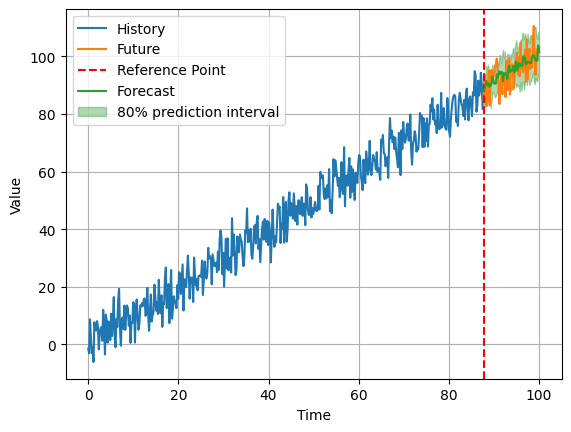

In [3]:
import torch
import matplotlib.pyplot as plt

# Generate data
a = torch.randn(512) * 5
b = torch.linspace(0, 100, 512)
data = a + b

# Define the split point
split_point = 512 - 64

# Plot the first segment
plt.plot(b[:split_point], data[:split_point], label='History')

# Plot the second segment, continuing from the first
plt.plot(b[split_point:], data[split_point:], label='Future')

# Add a vertical reference line at the break point
plt.axvline(x=b[split_point], color='red', linestyle='--', label='Reference Point')

import numpy as np
from chronos import ChronosPipeline

pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map="cpu",  # use "cpu" for CPU inference and "mps" for Apple Silicon
    # torch_dtype=torch.bfloat16,
)

forecast = pipeline.predict(context=data[:split_point].unsqueeze(0), prediction_length=64, num_samples=20)
low, median, high = np.quantile(forecast[0].numpy(), [0.1, 0.5, 0.9], axis=0)

plt.plot(b[split_point:], median, label='Forecast')
plt.fill_between(b[split_point:], low, high, color="green", alpha=0.3, label="80% prediction interval")

# Add labels and title
plt.xlabel('Time')
plt.ylabel('Value')
# Customize the plot
plt.grid()
plt.legend()
plt.show()



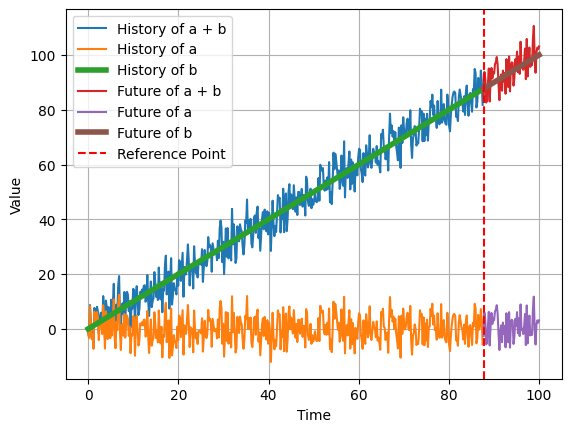

In [7]:
# Plot the first segment
plt.plot(b[:split_point], data[:split_point], label='History of a + b')
plt.plot(b[:split_point], a[:split_point], label='History of a')
# make this thicker
plt.plot(b[:split_point], b[:split_point], label='History of b', linewidth=4)

plt.plot(b[split_point:], data[split_point:], label='Future of a + b')

plt.plot(b[split_point:], a[split_point:], label='Future of a')
plt.plot(b[split_point:], b[split_point:], label='Future of b', linewidth=4)
# Plot the second segment, continuing from the first


# Add a vertical reference line at the break point
plt.axvline(x=b[split_point], color='red', linestyle='--', label='Reference Point')

# Add labels and title
plt.xlabel('Time')
plt.ylabel('Value')
# Customize the plot
plt.grid()
plt.legend()
plt.show()

In [58]:
def preprocess_entry(entry: dict) -> dict:
    drop_prob = 0.2
    entry = {f: entry[f] for f in ["start", "target"]}
    entry["target"] = np.asarray(entry["target"])
    assert entry["target"].ndim == 1, f"got {entry['target'].ndim=}, expected 1"

    if drop_prob > 0:
        target = entry["target"].copy()
        drop_p = np.random.uniform(low=0.0, high=drop_prob)
        mask = np.random.choice(
            [True, False], size=len(target), p=[drop_p, 1 - drop_p]
        )
        target[mask] = np.nan
        entry["target"] = target

    return entry, drop_prob, drop_p, mask

import numpy as np
entry = {"start": 0, "target": np.random.rand(10)}
preprocess_entry(entry)

({'start': 0,
  'target': array([0.65721505, 0.28088055, 0.11292491, 0.7918962 , 0.99950256,
         0.36749151, 0.25203605, 0.69542704, 0.45970618, 0.30848074])},
 0.2,
 0.06143017318741322,
 array([False, False, False, False, False, False, False, False, False,
        False]))

In [43]:
from gluonts.dataset.common import ListDataset
from gluonts.itertools import Cyclic
import numpy as np

data = ListDataset(
    [{"start": np.datetime64("2000-01-01 00:00", "h"), "target": np.random.rand(10)}],
    #  {"start": np.datetime64("2000-01-01 01:00", "h"), "target": np.random.rand(10)}],
    freq="h",
)

# data = Cyclic(data)
a = Cyclic([data[0]])
a

Cyclic(iterable=[{'start': Period('2000-01-01 00:00', 'h'), 'target': array([0.9070921 , 0.82340586, 0.10101887, 0.8337961 , 0.16665687,
       0.04200635, 0.8259445 , 0.41851327, 0.95946217, 0.9367955 ],
      dtype=float32)}])

In [44]:
idx = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
for i in idx:
    yield print(i)

SyntaxError: 'yield' outside function (2627784410.py, line 3)

In [52]:
# Example tensors
import torch
tensor_a = torch.tensor([5, 6, 7, 8]).unsqueeze(0) 
tensor_b = torch.tensor([13, 14, 15, 16]).unsqueeze(0)  
tensor_c = torch.tensor([23, 24, 25, 26]).unsqueeze(0)  
List_tensor = [tensor_b, tensor_c]

for tensor in List_tensor:
    tensor_a = torch.cat((tensor_a, tensor), dim=0)
# Concatenating along dim=0

tensor_a



tensor([[ 5,  6,  7,  8],
        [13, 14, 15, 16],
        [23, 24, 25, 26]])

In [12]:
import torch
from torch.utils.data import Dataset

class LazyTensorDataset(Dataset):
    def __init__(self, datasets):
        self.datasets = datasets  # List of lists of file paths

    def __len__(self):
        return len(self.datasets)

    def __getitem__(self, index):
        # Load tensors from file paths for the specific index
        inner_list = self.datasets[index]
        return [torch.load(path, weights_only=True) for path in inner_list]

# Step 2: Instantiate the lazy dataset
datasets = [
    ["./trainingData/contextTarget.pt", "./trainingData/context1.pt", "./trainingData/context2.pt"],
    ["./trainingData/context1.pt", "./trainingData/context1.pt", "./trainingData/context1.pt"]
]

probability = [1, 1]

lazy_tensor_dataset = LazyTensorDataset(datasets)

len(lazy_tensor_dataset[0])

3

In [6]:
import h5py
import torch
from torch.utils.data import Dataset


datasets = [
    ["./trainingData/contextTarget.pt", "./trainingData/context1.pt", "./trainingData/context2.pt"],
    ["./trainingData/context1.pt", "./trainingData/context1.pt", "./trainingData/context1.pt"]
]

with h5py.File('./trainingData/combined_tensors.h5', 'w') as f:
    for i, inner_list in enumerate(datasets):
        # Store each list of tensors in the HDF5 file
        f.create_dataset(f"dataset_{i}", data=[torch.load(path, weights_only=True) for path in inner_list])

In [30]:
class LazyTensorDataset(Dataset):
    def __init__(self, file_path):
        self.file_path = file_path

    def __len__(self):
        with h5py.File(self.file_path, 'r') as f:
            return len(f)  # Number of datasets stored in the HDF5 file

    def __getitem__(self, index):
        with h5py.File(self.file_path, 'r') as f:
            dataset_name = f"dataset_{index}"
            data = f[dataset_name][()]  # Load the tensor array for the given dataset
            # Convert the array into a list of tensors
            return [torch.tensor(item) for item in data]
        
lazy_tensor_dataset = LazyTensorDataset('./trainingData/combined_tensors.h5')

lazy_tensor_dataset = LazyTensorDataset('./scripts/MultivariateData.h5')

lazy_tensor_dataset[0]


[tensor([[-0.3176, -0.3180,  1.1947,  ...,  1.0073,  1.2297,  1.3880]],
        dtype=torch.float64),
 tensor([[-0.2197, -0.2172,  0.9317,  ...,  0.8315,  1.0025,  1.1224]],
        dtype=torch.float64),
 tensor([[-2.4111, -2.3100, -1.6388,  ..., -0.1708,  0.0065,  0.0646]],
        dtype=torch.float64)]